# Programming AI
## Practical AI Test: Classification and Regression with Penguins
### SVMs, Decision Trees and Linear Regression
### 20 marks

# Instructions

Please read the following instructions carefully before starting.

- You are allowed to consult **any code or notes stored on your computer**. This includes previous notebooks, exercises, or documentation you have written.
- **AI-assisted coding tools must be disabled** during this task. This includes tools such as **GitHub Copilot, ChatGPT, or any other AI code assistants**.
- You **do not need to answer the questions in order**, but your final notebook must run from top to bottom.
- If you need to search for programming help, you may only consult **StackOverflow**, **W3 schools**, **GeeksForGeeks** and the **Sklearn documentation**.  
  To do this, use the following restricted search link and type your query after it:

  https://www.google.com/search?q=site:stackoverflow.com+OR+site:geeksforgeeks.org+OR+w3schools.com+OR+sklearn.org
- Before submitting your work, click **`Run All`** to ensure that all cells execute correctly.
- Write short explanations where requested. Your explanations are part of the assessment.
- The data cleaning section has been completed for you. Your assessed work starts from **Part A**.

## Useful links:

- [SVMs documentation](https://scikit-learn.org/stable/modules/svm.html)
- [Decision Trees documentation](https://sklearn.org/stable/auto_examples/tree/index.html)
- [Linear Regression documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)


# Scenario

You are working as a junior data scientist for a research team studying penguins in Antarctica. The team has collected measurements from penguins, including their bill size, flipper length, body mass, sex, island and species.

Your task has two parts:

1. **Classification task:** build models that predict the **species** of a penguin.
2. **Regression task:** build a model that predicts the **body mass** of a penguin.

You will compare machine learning algorithms, evaluate them properly, and explain whether the models are performing well.

## Setup code

Run the following cells before starting the assessed questions.

In [79]:

# Import the libraries needed for this test
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [80]:
# Load the Palmer Penguins dataset

penguinsUrl = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv"

df = pd.read_csv(penguinsUrl)

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## Completed data cleaning code

The data cleaning process has already been completed for you because this test is focused on machine learning models.

The code below:

- keeps only the columns needed for this practical test,
- removes rows with missing values,
- resets the row index,
- creates a cleaned dataframe called **`cleanPenguins`**.

In [81]:

columnsToKeep = [
    "species",
    "island",
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
    "sex",
    "year"
]

cleanPenguins = df[columnsToKeep].copy()

# Make the sex column consistent
cleanPenguins["sex"] = cleanPenguins["sex"].str.lower()

# Remove rows with missing values
cleanPenguins = cleanPenguins.dropna().reset_index(drop=True)

# Convert categorical data to numerical
#cleanPenguins = pd.get_dummies(cleanPenguins, drop_first=True)

# Show the cleaned data
cleanPenguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [82]:

# Check that there are no missing values left
cleanPenguins.isna().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
year                 0
dtype: int64

In [83]:

# Basic information about the cleaned dataset
print("Number of rows:", len(cleanPenguins))
print("Number of columns:", len(cleanPenguins.columns))
print("Species:", cleanPenguins["species"].unique())

cleanPenguins

Number of rows: 333
Number of columns: 8
Species: <StringArray>
['Adelie', 'Gentoo', 'Chinstrap']
Length: 3, dtype: str


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007
...,...,...,...,...,...,...,...,...
328,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
329,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
330,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
331,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009



# Part A: Classification task

In this section, your goal is to predict the **species** of a penguin.

You will train and compare:

- a **Support Vector Machine classifier**,
- a **Decision Tree classifier**.

You may use the following feature columns:

- `bill_length_mm`
- `bill_depth_mm`
- `flipper_length_mm`
- `body_mass_g`
- `island`
- `sex`
- `year`



### Question 1
Prepare the data for the classification task.

You must:

1. Select appropriate input features.
2. Set `species` as the target variable.
4. Divide the data into a **training set** and a **validation set**.
5. Choose an appropriate percentage of the data to assign to the validation set.
6. Briefly explain why you chose that percentage.

<span style="color:red">(2 marks)</span>

In [84]:
classificationFeatures = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
    "island",
    "sex"
]

X = cleanPenguins[classificationFeatures].copy()
y = cleanPenguins["species"]

X = pd.get_dummies(X, columns=["island", "sex"], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3, random_state=42,stratify=y)

Features needec for classification,


### Question 2
Train a **Support Vector Machine classifier** using the default parameters.

<span style="color:red">(1 mark)</span>

In [85]:
svm_classifier = SVC(random_state=42)

svm_classifier.fit(X_train, y_train)

svm_predictions = svm_classifier.predict(X_test)
print("done")

done


### Question 3
Train a **Decision Tree classifier** using the default parameters.

<span style="color:red">(1 mark)</span>

In [86]:
dt_classifier = DecisionTreeClassifier(random_state=42)

dt_classifier.fit(X_train, y_train)

dt_predictions = dt_classifier.predict(X_test)

print("Done")

Done


### Question 4
Choose an appropriate metric to evaluate the two classification algorithms on the **validation set**.

You must:

1. State which metric you are using.
2. Calculate the result for the SVM classifier.
3. Calculate the result for the Decision Tree classifier.
4. Compare the two results.
5. Decide which model performs better on the validation set.

<span style="color:red">(2 marks)</span>

I am going to use accuracy

In [87]:
svm_accuracy = accuracy_score(y_test, svm_predictions)
print("SVM Accuracy on Validation", svm_accuracy)

dt_accuracy = accuracy_score(y_test, dt_predictions)
print("Decision Tree Accuracy on Validation", dt_accuracy)


SVM Accuracy on Validation 0.73
Decision Tree Accuracy on Validation 0.95


**Explanation:**\
Decision Tree performs better on validation

### Question 5
Compare the results on the **training set** as well.

You must:

1. Evaluate the SVM classifier on the training set.
2. Evaluate the Decision Tree classifier on the training set.
3. Compare the training and validation results.
4. Determine whether each model appears to be **overfitting**, **underfitting**, or performing appropriately.

<span style="color:red">(2 marks)</span>

In [88]:
svm_train_accuracy = accuracy_score(y_train, svm_train_predictions)
print("SVM Training Accuracy", svm_train_accuracy)

dt_train_accuracy = accuracy_score(y_train, dt_train_predictions)
print("Decision Tree Training Accuracy", dt_train_accuracy)


SVM Training Accuracy 0.721030042918455
Decision Tree Training Accuracy 1.0


**Explanation:**  
Write your explanation here. Use the words **overfitting** and/or **underfitting** where appropriate.\
SVM Accuracy on Validation 0.73\
Decision Tree Accuracy on Validation 0.95\
SVM Training Accuracy 0.721030042918455\
Decision Tree Training Accuracy 1.0

Given that the decision tree hit a 1.0 accuracy on training, it is quite obvious that it is overfitting
For the SVM however, it is at 0.72 for training and 0.73 on validation, given that it seems to be performing appropriately


### Question 6
Choose either the **SVM classifier** or the **Decision Tree classifier** and try to improve its performance by changing model parameters.

You must:

1. Make at least **three different parameter changes**.
2. Show the code for each version of the model.
3. Evaluate each version on both the training set and the validation set.
4. Present the results clearly.
5. Show which set of parameters gives the best.

<span style="color:red">(3 marks)</span>

The Decision Tree, it is overfitting, so its easier to fix...

In [89]:
# max depth 3
dt_v1 = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_v1.fit(X_train, y_train)

dt_v1_train_pred = dt_v1.predict(X_train)
dt_v1_test_pred = dt_v1.predict(X_test)

dt_v1_train_acc = accuracy_score(y_train, dt_v1_train_pred)
dt_v1_test_acc = accuracy_score(y_test, dt_v1_test_pred)

print("Training accuracy", dt_v1_train_acc)
print("Validation accuracy", dt_v1_test_acc)

Training accuracy 0.9871244635193133
Validation accuracy 0.98


In [90]:
#Max depth + Min split
dt_v2 = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)
dt_v2.fit(X_train, y_train)

dt_v2_train_pred = dt_v2.predict(X_train)
dt_v2_test_pred = dt_v2.predict(X_test)

dt_v2_train_acc = accuracy_score(y_train, dt_v2_train_pred)
dt_v2_test_acc = accuracy_score(y_test, dt_v2_test_pred)

print("Training accuracy", dt_v2_train_acc)
print("Validation accuracy", dt_v2_test_acc)

Training accuracy 0.9785407725321889
Validation accuracy 0.98


In [91]:
#Max depth, min split, min leaf
dt_v3 = DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5, random_state=42)
dt_v3.fit(X_train, y_train)

dt_v3_train_pred = dt_v3.predict(X_train)
dt_v3_test_pred = dt_v3.predict(X_test)

dt_v3_train_acc = accuracy_score(y_train, dt_v3_train_pred)
dt_v3_test_acc = accuracy_score(y_test, dt_v3_test_pred)

print("Training accuracy:", dt_v3_train_acc)
print("Validation accuracy:", dt_v3_test_acc)

Training accuracy: 0.9871244635193133
Validation accuracy: 0.95


### Question 7
Create a **confusion matrix** for your worst classification model.

Use the confusion matrix to determine:

1. Which penguin species are easier to classify.
2. Which penguin species are harder to classify.
3. Which species are most commonly confused with each other.

<span style="color:red">(2 marks)</span>

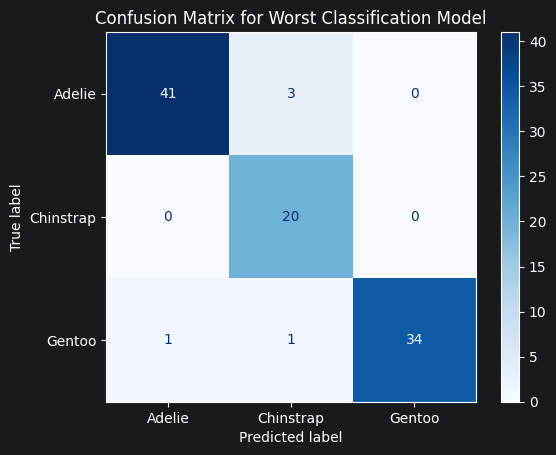

              precision    recall  f1-score   support

      Adelie       0.98      0.93      0.95        44
   Chinstrap       0.83      1.00      0.91        20
      Gentoo       1.00      0.94      0.97        36

    accuracy                           0.95       100
   macro avg       0.94      0.96      0.94       100
weighted avg       0.96      0.95      0.95       100



In [92]:
worst_model_predictions = dt_v3_test_pred

cm = confusion_matrix(y_test, worst_model_predictions, labels=svm_classifier.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_classifier.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix for Worst Classification Model")
plt.show()

print(classification_report(y_test, worst_model_predictions))

**Explanation:**
It has significant overfitting on all of the penguin , that is a first\
Adelie are the hardest to classify\
Gentoo are the easiest to classify

Adelie are the most likely to be confused with Chinstrap



# Part B: Regression task

The research team now wants to estimate the **body mass** of a penguin from the other available measurements.

In this section, your target variable is:

- `body_mass_g`

You will train a **Linear Regression** model.

### Question 8
Choose the **5 or 6 features** that you think are most appropriate for predicting the body mass of a penguin.

You must:

1. Choose your features.
2. Divide the data into training and validation sets.

<span style="color:red">(1 mark)</span>

In [93]:
regressionFeatures = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "island",
    "sex"
]

X_reg = cleanPenguins[regressionFeatures].copy()
y_reg = cleanPenguins["body_mass_g"]

X_reg = pd.get_dummies(X_reg, columns=["island", "sex"], drop_first=True)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

### Question 9
Train a **Linear Regression** model to predict penguin body mass.

<span style="color:red">(1 mark)</span>

In [94]:
lr_model = LinearRegression()
lr_model.fit(X_reg_train, y_reg_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Question 10
Evaluate the Linear Regression model on both the **training set** and the **validation set**.

You must calculate:

1. **MAE**: Mean Absolute Error
2. **RMSE**: Root Mean Squared Error
3. **R²**: Coefficient of determination

Then briefly explain what the results tell you about the model.

<span style="color:red">(3 marks)</span>

In [95]:
# Question 10: Evaluate the model

# Predictions
y_train_pred = lr_model.predict(X_reg_train)
y_test_pred = lr_model.predict(X_reg_test)

# Training
print("Training:")
print("MAE:", mean_absolute_error(y_reg_train, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_reg_train, y_train_pred)))
print("R^2:", r2_score(y_reg_train, y_train_pred))

# Validation
print("Validation:")
print("MAE:", mean_absolute_error(y_reg_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_reg_test, y_test_pred)))
print("R^2:", r2_score(y_reg_test, y_test_pred))

Training:
MAE: 265.49833943295977
RMSE: 327.51241689225475
R^2: 0.8445045169808802
Validation:
MAE: 264.04390122321945
RMSE: 319.0835298544685
R^2: 0.8106783447756979


**Explanation:**  
The training and validation perform very similarly, telling us that it is a good model and not overfitting. R^2 and RMSE show very good results.

### Question 11
Create visualisations showing the **actual body mass** compared with the **predicted body mass**.

You must create visualisations for:

1. The training set.
2. The validation set.

Your plots should have clear titles and axis labels.

<span style="color:red">(2 marks)</span>

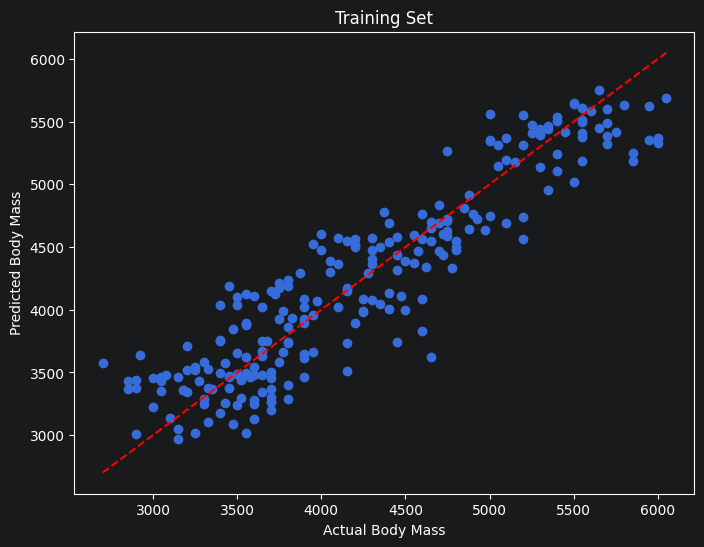

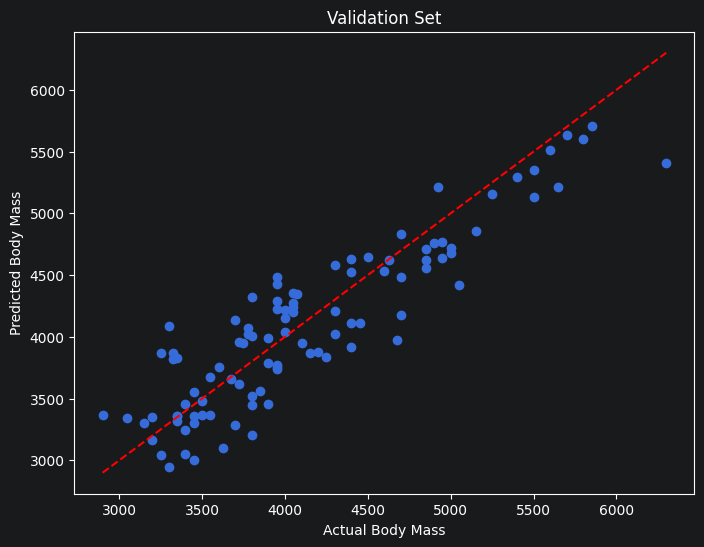

In [96]:
plt.figure(figsize=(8, 6))
plt.scatter(y_reg_train, y_train_pred)
plt.xlabel("Actual Body Mass")
plt.ylabel("Predicted Body Mass")
plt.title("Training Set")
plt.plot([y_reg_train.min(), y_reg_train.max()], [y_reg_train.min(), y_reg_train.max()], 'r--')
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(y_reg_test, y_test_pred)
plt.xlabel("Actual Body Mass")
plt.ylabel("Predicted Body Mass")
plt.title("Validation Set")
plt.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], 'r--')
plt.show()

**Explanation:**  
Write your interpretation of the visualisations here. Are the predictions close to the actual values?



# Part C: Bonus extension questions


### Bonus Question 1
Do any further improvements to either the classification algorithm or the regression algorithm.

You may use:

- additional feature engineering,
- different feature choices,
- further data cleaning decisions,
- parameter tuning,
- scaling,
- a different train/validation split,
- or another justified improvement.

Explain what you changed and whether it improved the model.

In [97]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [1, 2, 3, 5, 7, 10, 12, 15, 20, 25],
    'min_samples_split': [2, 3, 5, 7, 10, 15, 20, 25, 30],
    'min_samples_leaf': [1, 2, 3, 4, 5, 6, 8, 10, 12],
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'min_weight_fraction_leaf': [0.0, 0.01, 0.05],
    'max_features': ['sqrt', 'log2', None]
}

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42),param_grid,cv=5,scoring='accuracy')
dt_grid.fit(X_train, y_train)

print("Best parameters", dt_grid.best_params_)
print("Best score", dt_grid.best_score_)

Best parameters {'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 15, 'min_weight_fraction_leaf': 0.0, 'splitter': 'random'}
Best score 0.9786308973172988


**Explanation:**  
Using a grid search to find the best/most optimal combination of values (hyperparameter tuning) to find & determine the best way to configure decision tree.

### Bonus Question 2
Determine which factor appears to be the most relevant for predicting the body mass of penguins.

You may use one or more of the following approaches:

- correlation analysis,
- linear regression coefficients,
- visualisation,
- feature importance from a decision tree regressor.

Explain your reasoning clearly.

In [97]:
bill_length_mm

**Explanation:**  
guess